In [5]:
# 결측치가 있는지 확인 -> 없으므로 결측치 처리는 신경 x

import pandas as pd

# load the red and white wine quality datasets
red_wine = pd.read_csv('winequality-red.csv', delimiter=';')
white_wine = pd.read_csv('winequality-white.csv', delimiter=';')

# combine the two datasets
wine = pd.concat([red_wine, white_wine])

# check for missing values
print(wine.isnull().sum())


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
# 두개의 dataset을 합친 후 표준화(StandardScaler)를 진행함
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Show the head of the scaled wine dataframe
print(wine.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4          2.188833    -2.192833       -0.744778   0.569958   
1            7.8          3.282235    -2.192833       -0.597640   1.197975   
2            7.8          2.553300    -1.917553       -0.660699   1.026697   
3           11.2         -0.362438     1.661085       -0.744778   0.541412   
4            7.4          2.188833    -2.192833       -0.744778   0.569958   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0            -1.100140                  34.0   0.9978  3.51       0.56   
1            -0.311320                  67.0   0.9968  3.20       0.68   
2            -0.874763                  54.0   0.9970  3.26       0.65   
3            -0.762074                  60.0   0.9980  3.16       0.58   
4            -1.100140                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

<AxesSubplot:>

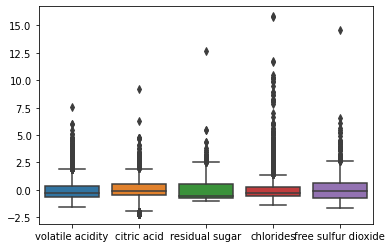

In [10]:
# 표준화 진행 전에 먼저 이상치가 있는지 봐야함.
# 데이터에 이상값이 너무 많으면 데이터의 평균 및 표준편차가 극단값의 영향을 많이 받을 수 있기 때문에 표준 스케일링 수행이 어려울 수 있습니다
# 이러한 경우 scikit-learn의 RobustScaler와 같이 이상값에 덜 민감한 강력한 스케일러를 사용하는 것이 더 나을 수 있습니다.
import seaborn as sns

# Create boxplots to visualize outliers
sns.boxplot(data=scaled_df)


In [11]:
# 와인 품질 데이터 세트를 적포도주 및 백포도주 데이터와 결합하고 scikit-learn의 RobustScaler를 사용하여 표준화를 적용하는 예제 코드입니다.
# 이 코드에서는 scikit-learn의 RobustScaler를 사용하여 선택한 변수의 크기를 조정합니다. 
# RobustScaler는 StandardScaler에 비해 이상값에 덜 민감하므로 데이터에 많은 수의 이상값이 포함된 경우 좋은 선택입니다.

# 범주형 데이터 변수는 없기 때문에 범주형 데이터처리는 생각X

from sklearn.preprocessing import RobustScaler
import pandas as pd

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Show the head of the scaled wine dataframe
print(wine.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4          2.411765    -2.214286       -0.174603   1.074074   
1            7.8          3.470588    -2.214286       -0.063492   1.888889   
2            7.8          2.764706    -1.928571       -0.111111   1.666667   
3           11.2         -0.058824     1.785714       -0.174603   1.037037   
4            7.4          2.411765    -2.214286       -0.174603   1.074074   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0            -0.750000                  34.0   0.9978  3.51       0.56   
1            -0.166667                  67.0   0.9968  3.20       0.68   
2            -0.583333                  54.0   0.9970  3.26       0.65   
3            -0.500000                  60.0   0.9980  3.16       0.58   
4            -0.750000                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value 

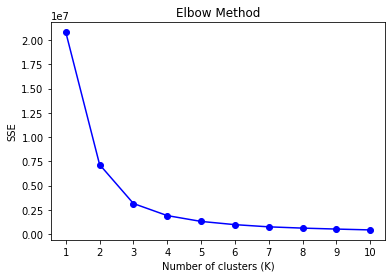

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Load the data
# (Assuming that the data has already been preprocessed and scaled)

# Define the range of K values to test
k_values = range(1, 11)

# Initialize empty lists to store SSE (sum of squared errors) values for different K values
sse = []

# Apply K-means clustering for different K values and calculate SSE for each
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(wine)
    sse.append(kmeans.inertia_)

# Plot the SSE values for different K values
plt.plot(k_values, sse, 'o-', color='b')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.xticks(np.arange(min(k_values), max(k_values)+1, 1.0))
plt.show()


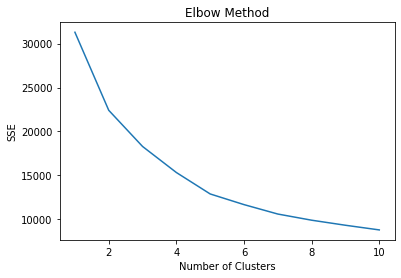

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Use elbow method to find optimal k
SSE = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled)
    SSE.append(kmeans.inertia_)

# Plot SSE for each k value
plt.plot(range(1, 11), SSE)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()


C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


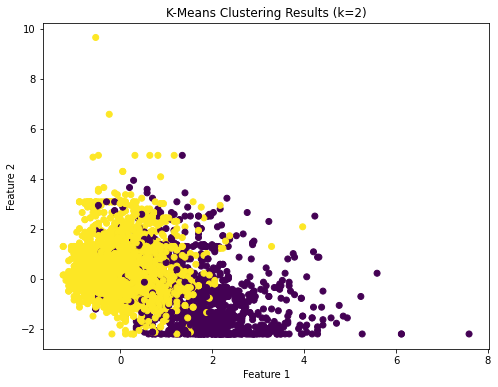

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Fit k-means clustering algorithm with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled)

# Predict the cluster labels
labels = kmeans.predict(scaled)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(scaled[:, 0], scaled[:, 1], c=labels, cmap='viridis')
plt.title('K-Means Clustering Results (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


In [14]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Calculate the silhouette score for k=2
silhouette = silhouette_score(scaled, labels)
print(f"Silhouette score (k=2): {silhouette:.3f}")

# Calculate the Calinski-Harabasz score for k=2
ch_score = calinski_harabasz_score(scaled, labels)
print(f"Calinski-Harabasz score (k=2): {ch_score:.3f}")

# Calculate the Davies-Bouldin score for k=2
db_score = davies_bouldin_score(scaled, labels)
print(f"Davies-Bouldin score (k=2): {db_score:.3f}")


Silhouette score (k=2): 0.400
Calinski-Harabasz score (k=2): 2573.163
Davies-Bouldin score (k=2): 1.238


In [7]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df


Silhouette score for ward linkage: 0.563


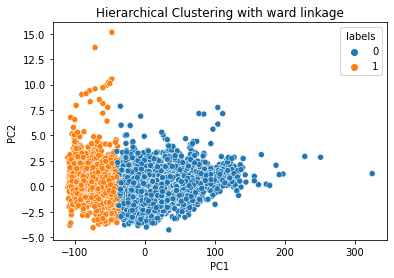

Silhouette score for complete linkage: 0.640


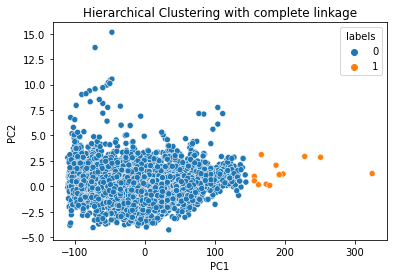

Silhouette score for average linkage: 0.640


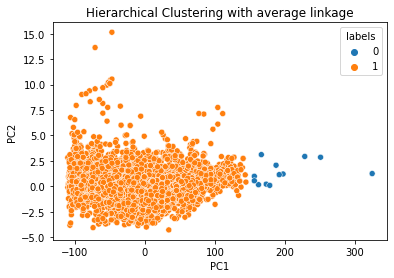

Silhouette score for single linkage: 0.793


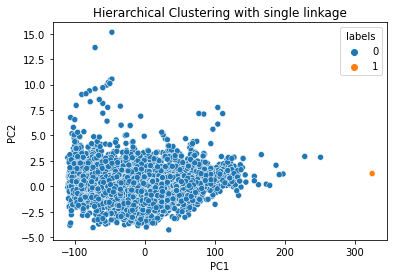

In [11]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Perform hierarchical clustering with different linkage methods
linkage_methods = ["ward", "complete", "average", "single"]
for method in linkage_methods:
    # Initialize the hierarchical clustering algorithm
    hc = AgglomerativeClustering(n_clusters=2, linkage=method)
    
    # Fit the algorithm to the wine dataset
    hc.fit(wine)
    
    # Obtain the cluster labels
    labels = hc.labels_
    
    # Calculate the silhouette score
    silhouette_avg = silhouette_score(wine, labels)
    print(f"Silhouette score for {method} linkage: {silhouette_avg:.3f}")
    
    # Visualize the clusters using the first two principal components
    pca = PCA(n_components=2)
    components = pca.fit_transform(wine)
    components_df = pd.DataFrame(data=components, columns=["PC1", "PC2"])
    components_df["labels"] = labels
    sns.scatterplot(x="PC1", y="PC2", hue="labels", data=components_df)
    plt.title(f"Hierarchical Clustering with {method} linkage")
    plt.show()

In [ ]:
# Calculate the mean quality of each cluster
cluster1_quality = wine.iloc[hc.labels_ == 0]["quality"].mean()
cluster2_quality = wine.iloc[hc.labels_ == 1]["quality"].mean()

# Print the mean quality of each cluster
print(f"Cluster 1 mean quality: {cluster1_quality:.3f}")
print(f"Cluster 2 mean quality: {cluster2_quality:.3f}")

# Assign labels to each cluster based on mean quality
hc_labels_quality = [1 if x >= (cluster1_quality+cluster2_quality)/2 else 0 for x in hc_labels]

# Calculate the accuracy of hierarchical clustering compared to quality labels
accuracy_hc_quality = sum(hc_labels_quality == wine["quality"]) / len(wine["quality"])

print(f"Accuracy of hierarchical clustering compared to quality labels: {accuracy_hc_quality:.3f}")


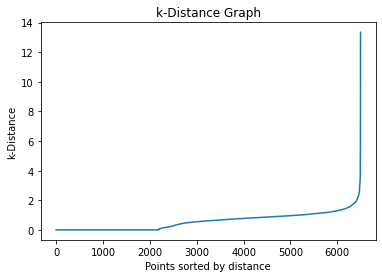

eps: 0.100, Silhouette score: -0.480
eps: 0.200, Silhouette score: -0.474
eps: 0.300, Silhouette score: -0.465
eps: 0.400, Silhouette score: -0.452
eps: 0.500, Silhouette score: -0.426
eps: 0.600, Silhouette score: -0.378
eps: 0.700, Silhouette score: -0.318
eps: 0.800, Silhouette score: -0.281
eps: 0.900, Silhouette score: -0.305
eps: 1.000, Silhouette score: -0.367
eps: 1.100, Silhouette score: -0.367
eps: 1.200, Silhouette score: -0.342
eps: 1.300, Silhouette score: -0.378
eps: 1.400, Silhouette score: -0.336
eps: 1.500, Silhouette score: -0.294
eps: 1.600, Silhouette score: -0.214
eps: 1.700, Silhouette score: -0.044
eps: 1.800, Silhouette score: -0.028
eps: 1.900, Silhouette score: 0.169
eps: 2.000, Silhouette score: 0.097
eps: 2.100, Silhouette score: 0.124
eps: 2.200, Silhouette score: 0.158
eps: 2.300, Silhouette score: 0.159
eps: 2.400, Silhouette score: 0.139
eps: 2.500, Silhouette score: 0.271
eps: 2.600, Silhouette score: 0.316
eps: 2.700, Silhouette score: 0.316
eps: 2.800

In [12]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be used for clustering
X = wine[["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]]

# Scale the variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute k-distance graph
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
plt.title("k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("k-Distance")
plt.show()

# Compute silhouette score for different values of eps
eps_list = np.linspace(0.1, 3, num=30)
for eps in eps_list:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan.fit(X_scaled)
    labels = dbscan.labels_
    if len(np.unique(labels)) > 1:
        silhouette_avg = silhouette_score(X_scaled, labels)
    else:
        silhouette_avg = -1
    print(f"eps: {eps:.3f}, Silhouette score: {silhouette_avg:.3f}")

# Cluster the data with DBSCAN using the tuned hyperparameters
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(X_scaled)
labels = dbscan.labels_


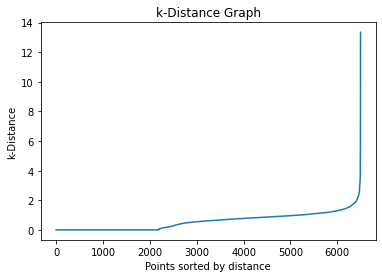

eps: 0.100, Silhouette score: -0.480
eps: 0.200, Silhouette score: -0.474
eps: 0.300, Silhouette score: -0.465
eps: 0.400, Silhouette score: -0.452
eps: 0.500, Silhouette score: -0.426
eps: 0.600, Silhouette score: -0.378
eps: 0.700, Silhouette score: -0.318
eps: 0.800, Silhouette score: -0.281
eps: 0.900, Silhouette score: -0.305
eps: 1.000, Silhouette score: -0.367
eps: 1.100, Silhouette score: -0.367
eps: 1.200, Silhouette score: -0.342
eps: 1.300, Silhouette score: -0.378
eps: 1.400, Silhouette score: -0.336
eps: 1.500, Silhouette score: -0.294
eps: 1.600, Silhouette score: -0.214
eps: 1.700, Silhouette score: -0.044
eps: 1.800, Silhouette score: -0.028
eps: 1.900, Silhouette score: 0.169
eps: 2.000, Silhouette score: 0.097
eps: 2.100, Silhouette score: 0.124
eps: 2.200, Silhouette score: 0.158
eps: 2.300, Silhouette score: 0.159
eps: 2.400, Silhouette score: 0.139
eps: 2.500, Silhouette score: 0.271
eps: 2.600, Silhouette score: 0.316
eps: 2.700, Silhouette score: 0.316
eps: 2.800

KeyboardInterrupt: 

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be used for clustering
X = wine[["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]]

# Scale the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute pairwise distances between samples
D = pairwise_distances(X_scaled)

# Compute k-distance graph
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
plt.title("k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("k-Distance")
plt.show()

# Compute silhouette score for different values of eps
eps_list = np.linspace(0.1, 3, num=30)
for eps in eps_list:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan.fit(X_scaled)
    labels = dbscan.labels_
    if len(np.unique(labels)) > 1:
        silhouette_avg = silhouette_score(X_scaled, labels)
    else:
        silhouette_avg = -1
    print(f"eps: {eps:.3f}, Silhouette score: {silhouette_avg:.3f}")

# Cluster the data with DBSCAN using the tuned hyperparameters
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(X_scaled)
labels = dbscan.labels_

# Compute SSE
sse = 0
for i in range(np.max(labels)+1):
    cluster_points = X_scaled[labels == i]
    centroid = np.mean(cluster_points, axis=0)
    sse += np.sum((cluster_points - centroid)**2)

# Compute Silhouette score
if len(np.unique(labels)) > 1:
    silhouette_avg = silhouette_score(X_scaled, labels)
else:
    silhouette_avg = -1

print(f"DBSCAN Clustering - Number of clusters: {np.max(labels)+1}, SSE: {sse:.3f}, Silhouette score: {silhouette_avg:.3f}")


In [18]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Save the preprocessed wine dataset to csv file
wine.to_csv("wine.csv", index=False)


In [22]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read in the preprocessed wine dataset
wine = pd.read_csv("wine.csv")

# Select the variables to be used for clustering
X = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density"]]

# Scale the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform DBSCAN clustering with tuned hyperparameters
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(X_scaled)
labels = dbscan.labels_

# Visualize the clustering results
colors = np.array(["#000000", "#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF"])
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color=colors[labels])
plt.title("DBSCAN Clustering Results")
plt.xlabel("Volatile Acidity")
plt.ylabel("Citric Acid")
plt.show()

# Compute and print the Silhouette score
silhouette_avg = silhouette_score(X_scaled, labels)
print(f"Silhouette score: {silhouette_avg:.3f}")


IndexError: index 7 is out of bounds for axis 0 with size 7

Number of clusters: 34
Number of noise points: 244
Silhouette score: -0.122


C:\Users\dlxod\AppData\Local\Temp\ipykernel_3024\4265017134.py:51: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  colors = np.array(['#000000'] + [plt.cm.Spectral(i) for i in np.linspace(0, 1, len(set(labels)))])


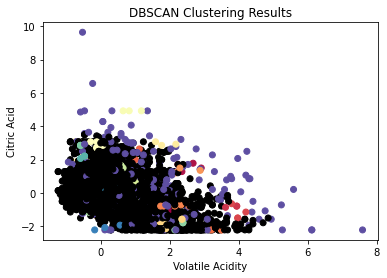

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Read in the red wine dataset
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")

# Read in the white wine dataset
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

# Combine the two datasets
wine = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Select the variables to be scaled
to_scale = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Scale the selected variables using RobustScaler
scaler = RobustScaler()
scaled = scaler.fit_transform(to_scale)

# Convert the scaled variables back to a dataframe
scaled_df = pd.DataFrame(scaled, columns=["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"])

# Replace the unscaled variables in the wine dataframe with the scaled ones
wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]] = scaled_df

# Select the variables to be used for clustering
X = wine[["volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide"]]

# Perform DBSCAN clustering with tuned hyperparameters
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(X)
labels = dbscan.labels_

# Calculate the number of clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

# Print the number of clusters and noise points
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Compute and print the Silhouette score
silhouette_avg = silhouette_score(X, labels)
print(f"Silhouette score: {silhouette_avg:.3f}")

# Create a color map for the clusters
colors = np.array(['#000000'] + [plt.cm.Spectral(i) for i in np.linspace(0, 1, len(set(labels)))])
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], color=colors[labels])
plt.title("DBSCAN Clustering Results")
plt.xlabel("Volatile Acidity")
plt.ylabel("Citric Acid")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler

# Load the wine dataset
wine_data = pd.read_csv('winequality-white.csv', delimiter=';')

# Select the variables to be used for clustering
to_cluster = wine_data[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
                        'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(to_cluster)

# Perform hierarchical clustering using complete linkage method
plt.figure(figsize=(10, 7))
dend = shc.dendrogram(shc.linkage(scaled_data, method='complete'))

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Wine Samples')
plt.ylabel('Distance')
plt.show()


In [34]:
from sklearn.cluster import KMeans
import seaborn as sns

# DBSCAN clustering without quality feature
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan.fit(X)
labels1 = dbscan.labels_

# K-means clustering with quality feature
kmeans = KMeans(n_clusters=6)
kmeans.fit(wine)
labels2 = kmeans.labels_

# Add clustering labels to wine dataframe
wine['DBSCAN_labels'] = labels1
wine['KMeans_labels'] = labels2

# Visualize DBSCAN clustering results
colors1 = np.array(["#000000", "#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF"])
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], color=colors1[labels1])

plt.title("DBSCAN Clustering Results")
plt.xlabel("Volatile Acidity")
plt.ylabel("Citric Acid")
plt.show()

# Visualize K-means clustering results
colors2 = sns.color_palette('bright', n_colors=6)
plt.scatter(wine['volatile acidity'], wine['citric acid'], c=labels2, cmap=colors2)
plt.title("K-means Clustering Results with Quality Feature")
plt.xlabel("Volatile Acidity")
plt.ylabel("Citric Acid")
plt.show()


C:\Users\dlxod\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


IndexError: index 7 is out of bounds for axis 0 with size 7